In [2]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

In [26]:
print("HEllo")

HEllo


In [3]:
print(df.shape)

print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nul

In [4]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

In [5]:
import seaborn as sns
df = sns.load_dataset("titanic")
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


In [6]:
df["embark_town"] = df["embark_town"].replace({
    "Southampton ": "Southampton",
    "southampton": "Southampton"
})

In [7]:
print(df.dtypes)

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [8]:
df["age"] = df["age"].fillna(
    df["age"].median()
)

In [9]:
df_raw = sns.load_dataset("titanic")
df = df_raw.copy()

In [10]:
import seaborn as sns

df = sns.load_dataset("titanic")

# handle missing values in deck safely
if "deck" in df.columns:
    df["deck"] = df["deck"].cat.add_categories("Unknown")
    df["deck"] = df["deck"].fillna("Unknown")

print(df[["deck"]].head())

      deck
0  Unknown
1        C
2  Unknown
3        C
4  Unknown


In [11]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck             0
embark_town      2
alive            0
alone            0
dtype: int64


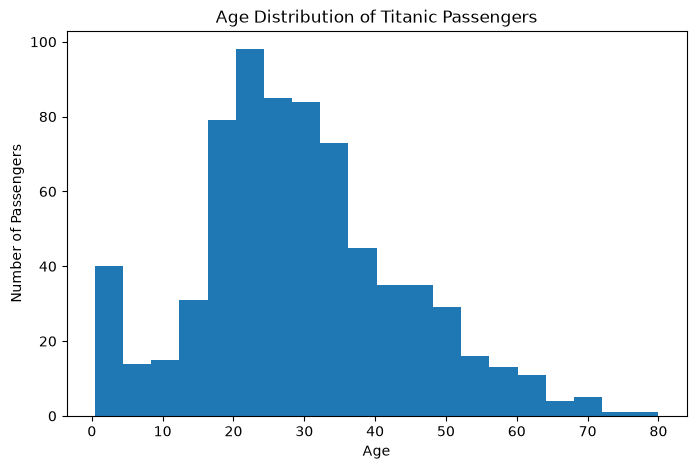

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

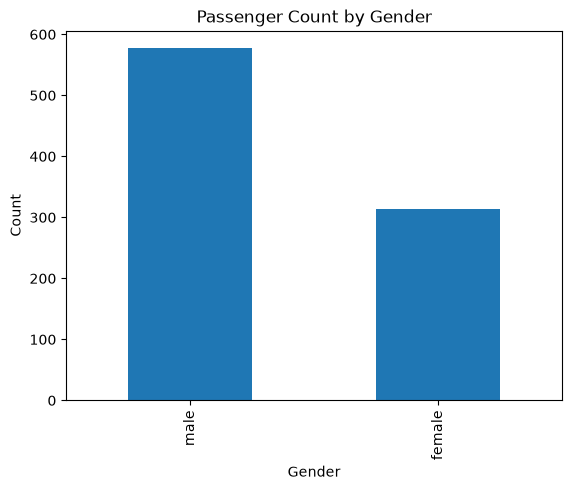

In [13]:
df["sex"].value_counts().plot(kind="bar")

plt.title("Passenger Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

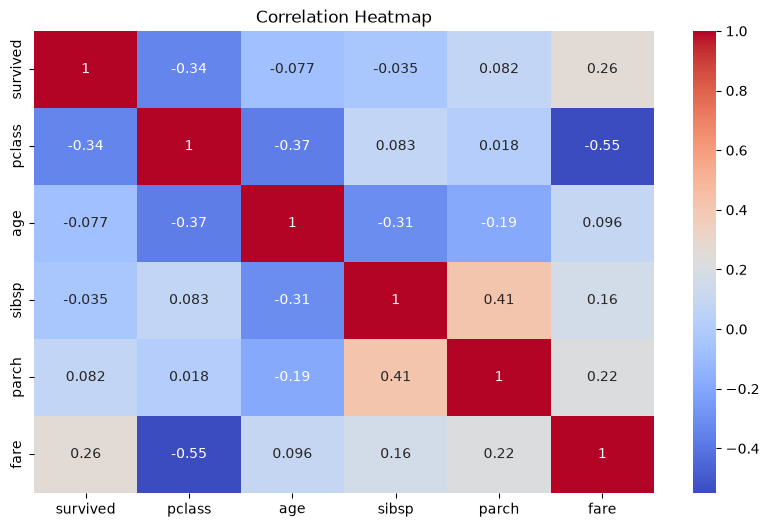

In [14]:
import seaborn as sns

numeric = df.select_dtypes(include="number")

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

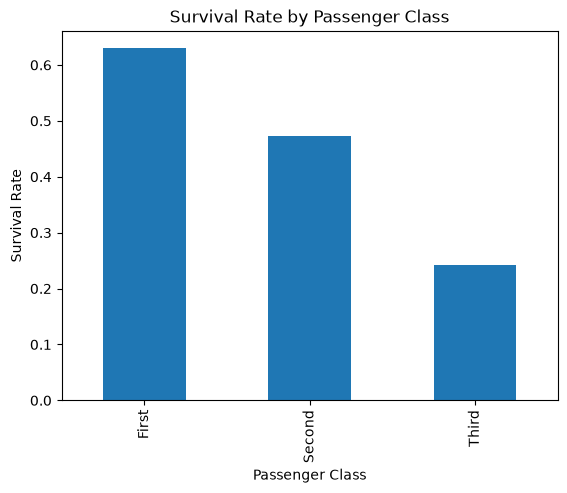

In [15]:
survival_rate = (
    df.groupby("class")["survived"]
      .mean()
)

survival_rate.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [16]:
df["family_size"] = (
    df["sibsp"] +
    df["parch"] + 1
)

In [17]:
df["is_alone"] = (
    df["family_size"] == 1
).astype(int)

In [18]:
df.groupby("sex")["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [19]:
df.groupby("class")["survived"].mean()

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

In [20]:
df.groupby("survived")["fare"].mean()

survived
0    22.117887
1    48.395408
Name: fare, dtype: float64

In [21]:
df.groupby("is_alone")["survived"].mean() 

is_alone
0    0.505650
1    0.303538
Name: survived, dtype: float64

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
 15  family_size  891 non-null    int64   
 16  is_alone     891 non-null    int64   
dtypes: bool(2), category(2), float64(2), int64(6), str(5)
memory usage: 94.6 KB


In [23]:
# Convert boolean to int
df['alone'] = df['alone'].astype(int)

# Keep only numeric columns
df = df.select_dtypes(include=['int64', 'float64'])

# Check result
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   age          714 non-null    float64
 3   sibsp        891 non-null    int64  
 4   parch        891 non-null    int64  
 5   fare         891 non-null    float64
 6   alone        891 non-null    int64  
 7   family_size  891 non-null    int64  
 8   is_alone     891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB
None


In [24]:
print(df.columns)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'alone',
       'family_size', 'is_alone'],
      dtype='str')


In [25]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   age          714 non-null    float64
 3   sibsp        891 non-null    int64  
 4   parch        891 non-null    int64  
 5   fare         891 non-null    float64
 6   alone        891 non-null    int64  
 7   family_size  891 non-null    int64  
 8   is_alone     891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB
None
   survived  pclass   age  sibsp  parch     fare  alone  family_size  is_alone
0         0       3  22.0      1      0   7.2500      0            2         0
1         1       1  38.0      1      0  71.2833      0            2         0
2         1       3  26.0      0      0   7.9250      1            1         1
3         1       1  35.0      1      0  53.1000      0            2     